In [1]:
#libraries for file handling
import os
from pathlib import Path
import shutil
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

#libraries for opening hdf5 database files
import h5py

#pytorch
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.nn.functional as F

#modules for math
import numpy as np

#module for timing the length of epochs
import time

#module for accessing files from google drive
from google.colab import drive


In [11]:
#File Handling: moving files to local directories



#mounting google drive
drive.mount('/content/drive', force_remount=True)

# Create a local directory to store the HDF5 files
local_train_dir = '/content/local_training_data'
local_val_dir = '/content/local_validation_data'
local_test_dir = '/content/local_test_data'

os.makedirs(local_train_dir, exist_ok=True)
print(f"Local directory created at: {local_train_dir}")
os.makedirs(local_val_dir, exist_ok=True)
print(f"Local directory created at: {local_val_dir}")
os.makedirs(local_test_dir, exist_ok=True)
print(f"Local directory created at: {local_test_dir}")

#code for copying files from "drive" folder to local folders

def copy_file_robustly(src, dst, chunk_size=65536):
    """Copies a file from src to dst using a chunked read/write approach."""
    try:
        with open(src, 'rb') as fsrc:
            with open(dst, 'wb') as fdst:
                while True:
                    buf = fsrc.read(chunk_size)
                    if not buf:
                        break
                    fdst.write(buf)
    except OSError as e:
        print(f"Error copying file {src} to {dst}: {e}")
        raise # Re-raise the exception after printing

train_data_path = Path('/content/drive/MyDrive/downsampledTrainingData/Train')
print(f"Copying files from {train_data_path} to {local_train_dir}...")
for h5_file in train_data_path.glob("*.h5"):
     copy_file_robustly(h5_file, os.path.join(local_train_dir, h5_file.name))
print("Finished copying training files.")

val_data_path = Path('/content/drive/MyDrive/downsampledTrainingData/Validation')
print(f"Copying files from {val_data_path} to {local_val_dir}...")
for h5_file in val_data_path.glob("*.h5"):
     copy_file_robustly(h5_file, os.path.join(local_val_dir, h5_file.name))
print("Finished copying validation files.")

test_data_path = Path('/content/drive/MyDrive/downsampledTrainingData/Test')
print(f"Copying files from {test_data_path} to {local_test_dir}...")
for h5_file in test_data_path.glob("*.h5"):
     copy_file_robustly(h5_file, os.path.join(local_test_dir, h5_file.name))
print("Finished copying test files.")


#file_lists for train, validation and test scans
local_folder_path = Path(train_data_path)
train_list = [f.stem for f in local_folder_path.glob("*.h5")]
print(f"Updated file_list with {len(train_list)} local files.")

local_folder_path = Path(val_data_path)
val_list = [f.stem for f in local_folder_path.glob("*.h5")]
print(f"Updated file_list with {len(val_list)} local files.")

local_folder_path = Path(test_data_path)
test_list = [f.stem for f in local_folder_path.glob("*.h5")]
print(f"Updated file_list with {len(test_list)} local files.")

Mounted at /content/drive
Local directory created at: /content/local_training_data
Local directory created at: /content/local_validation_data
Local directory created at: /content/local_test_data
Copying files from /content/drive/MyDrive/downsampledTrainingData/Train to /content/local_training_data...
Finished copying training files.
Copying files from /content/drive/MyDrive/downsampledTrainingData/Validation to /content/local_validation_data...
Finished copying validation files.
Copying files from /content/drive/MyDrive/downsampledTrainingData/Test to /content/local_test_data...
Finished copying test files.
Updated file_list with 973 local files.
Updated file_list with 324 local files.
Updated file_list with 324 local files.


In [134]:
class UNet3D(nn.Module):
    #in_channels: Number of input features (for each brain scan there are 4 features as there are 4 MRI modalities)
    #out_channels: Number of output labels (there are 5 possible labels for each pixel in the brain scan)
    #features: Number of input features for each encoder (ex. first encoder input is 8, second encoder input is 16, etc.) The length of the list is the number of encoders/decoders
    #4 different combinations of features: [8,16,32]: 3 layers, low feature count [8,16,32,64]: 4 layers, low feature count
    # [16,32,64]: 3 layers, high feature count [16,32,64,128]: 4 layers, high feature count
    def __init__(self, in_channels=4, out_channels=5, features=[16,32,64]):
        super(UNet3D, self).__init__()

        #Encoders: Each encoder has two convolution operations. The output of the encoder is MaxPool3d which halves each of the dimensions
        #Each encoder has double the amount of output features as input features
        self.encoders = nn.ModuleList()
        for f in features:
            self.encoders.append(self.conv_block(in_channels, f))
            in_channels = f
        self.pool = nn.MaxPool3d(2)

        #Bottleneck: Small image size but feature heavy
        self.bottleneck = self.conv_block(features[-1], features[-1]*2)


        #Decoder: Each decoder's input is the concatenation (along the feature dimension)
        #of the up convolution of the previous output and the skip connection of an encoder
        self.upconvs = nn.ModuleList()
        self.decoders = nn.ModuleList()
        rev_features = features[::-1]

        #each decoder has half as many features as the previous decoder but the image size doubles in every spatial direction (x,y,z)
        in_ch_decoder = features[-1] * 2
        for f in rev_features:
            self.upconvs.append(nn.ConvTranspose3d(in_ch_decoder, f, kernel_size=2, stride=2))
            self.decoders.append(self.conv_block(f*2, f))
            in_ch_decoder = f

        # Final convolution that is used to calculate probabilities of all 5 labels
        self.final_conv = nn.Conv3d(features[0], out_channels, kernel_size=1)

    #convolution block: each encoder and decoder consists of one of these
    #Can switch between batch normalization and instance normalization
    def conv_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            # nn.InstanceNorm3d(out_ch),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            # nn.InstanceNorm3d(out_ch),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        skip_connections = []

        # Encoders
        for enc in self.encoders:
            x = enc(x)
            skip_connections.append(x)
            x = self.pool(x)

        # Bottleneck
        x = self.bottleneck(x)

        # Decoder
        skip_connections = skip_connections[::-1]
        for idx in range(len(self.decoders)):
            x = self.upconvs[idx](x)
            skip = skip_connections[idx] #skip connection from the output of the encoder
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[2:], mode='trilinear', align_corners=False) #interpolation of upsampled output to match the shape of the skip connection
            #concatenating skip connection and upconvolution along the feature axis
            x = torch.cat([skip, x], dim=1)
            x = self.decoders[idx](x)

        return self.final_conv(x) # Outputs shape [Batch, 5, 91, 109, 91]

In [135]:
def dice_score(pred, target, num_classes=5, smooth=1e-6):
    # convert output of model to probabilities using softmax function
    probs = F.softmax(pred, dim=1)
    #convert targets to one hot
    target_one_hot = F.one_hot(target.long(), num_classes=num_classes).permute(0, 4, 1, 2, 3).float()

    dice = 0
    for c in range(num_classes):
        pred_c = (torch.argmax(probs, dim=1) == c).float()
        target_c = target_one_hot[:, c, ...]

        #finding intersection and union of the two masks
        intersection = (pred_c * target_c).sum(dim=(1, 2, 3))
        union = pred_c.sum(dim=(1, 2, 3)) + target_c.sum(dim=(1, 2, 3))

        #calculating dice score
        dice += (2. * intersection + smooth) / (union + smooth)

    #averaging over classes and batch
    return (dice / num_classes).mean().item()

def dice_loss(logits, targets, num_classes=5, smooth=1e-6):
    # convert output of model to probabilities using softmax function
    probs = F.softmax(logits, dim=1)
    #convert target to one hot
    target_one_hot = F.one_hot(targets.long(), num_classes=num_classes).permute(0, 4, 1, 2, 3).float()

    dice = 0
    for c in range(num_classes):
        pred_c = probs[:, c, ...]
        target_c = target_one_hot[:, c, ...]

        #finding intersection and union of the two masks
        intersection = (pred_c * target_c).sum(dim=(1, 2, 3))
        union = pred_c.sum(dim=(1, 2, 3)) + target_c.sum(dim=(1, 2, 3))

        #calculating dice score
        dice += (2. * intersection + smooth) / (union + smooth)

    #averaging over classes and batch
    return 1 - (dice / num_classes).mean()

In [136]:
class brainDataset(Dataset):
    def __init__(self, file_list, data_dir):
        self.file_list = file_list
        self.data_dir = data_dir

    def __len__(self):
        return len(self.file_list)

    def __getitem__(self, idx):
        file_path = os.path.join(self.data_dir, self.file_list[idx] + '.h5')

        with h5py.File(file_path, 'r') as f:
            keys = list(f.keys())
            inputs = np.array(f[keys[0]], dtype=np.float32)
            targets = np.array(f[keys[1]], dtype=np.int8)

        # Convert to tensors
        inputs_tensor = torch.from_numpy(inputs)
        targets_tensor = torch.from_numpy(targets).long()

        # --- Z-score normalization (per channel) ---
        # shape assumed: (H, W, D, C)
        mean = inputs_tensor.mean(dim=(0, 1, 2), keepdim=True)
        std = inputs_tensor.std(dim=(0, 1, 2), keepdim=True)

        # avoid division by zero
        std = std + 1e-8

        inputs_tensor = (inputs_tensor - mean) / std

        # permute to (C, H, W, D)
        inputs_tensor = inputs_tensor.permute(3, 0, 1, 2)

        return inputs_tensor, targets_tensor

In [137]:
def train(model, loss_function, num_epochs):
    optimizer = torch.optim.Adam(model.parameters(), lr = 0.001, eps=1e-4)

    #values to plot
    train_loss_list = []
    train_dice_score_list = []
    val_loss_list = []
    val_dice_score_list = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_dice_score = 0.0
        val_loss = 0.0
        val_dice_score = 0.0

        start_epoch = time.time()
        # training loop
        for i, data in enumerate(train_loader):
            # get the inputs
            inputs, labels = data

            inputs = inputs.to(device)
            labels = labels.to(device)

            # reshape input
            inputs = inputs.squeeze(1)

            # forward pass
            optimizer.zero_grad()
            outputs = model.forward(inputs)

            # compute loss: DICE loss
            loss = loss_function(outputs, labels)

            # backward pass
            loss.backward()
            optimizer.step()

            # update training loss and accuracy
            train_loss += loss.item()
            train_dice_score += dice_score(outputs, labels)


        #calculating validation loss and score
        model.eval()
        with torch.no_grad():
          for i, data in enumerate(val_loader):
            inputs, labels = data

            inputs = inputs.to(device)
            labels = labels.to(device)

            # reshape input
            inputs = inputs.squeeze(1)

            outputs = model.forward(inputs)
            loss = loss_function(outputs, labels)
            val_loss += loss.item()
            val_dice_score += dice_score(outputs, labels)

        #appending loss and scores to arrays
        train_loss_list.append(train_loss/len(train_loader))
        val_loss_list.append(val_loss/len(val_loader))
        train_dice_score_list.append(train_dice_score/len(train_loader))
        val_dice_score_list.append(val_dice_score/len(val_loader))

        end_epoch = time.time()
        epoch_time = end_epoch - start_epoch
        print(f"Total time for epoch: {epoch_time}")

        print('Epoch:%d|Train Loss:%.4f|Train Dice:%.2f|Val Loss:%.4f|Val Dice:%.2f'
        %(epoch+1, train_loss / len(train_loader), train_dice_score / len(train_loader),val_loss/len(val_loader),val_dice_score/len(val_loader)))
    return train_loss_list, train_dice_score_list, val_loss_list, val_dice_score_list

#evaluating test loss and test dice score after training model
def test(model, loss_function):
  model.eval()
  test_loss = 0
  test_dice_score = 0
  with torch.no_grad():
    for i, data in enumerate(test_loader):
            inputs, labels = data

            inputs = inputs.to(device)
            labels = labels.to(device)
            inputs = inputs.squeeze(1)

            outputs = model.forward(inputs)
            loss = loss_function(outputs, labels)
            test_loss += loss.item()
            test_dice_score += dice_score(outputs, labels)
  print(f"Test Loss: {test_loss/len(test_loader)}")
  print(f"Test Dice Score: {test_dice_score/len(test_loader)}")




In [138]:
import matplotlib.pyplot as plt

#batch size parameter: 4 or 16
batch_size = 4

#creaing datasets and data loaders for datasets with batch size = batch_size
train_set = brainDataset(train_list,local_train_dir)
train_loader = DataLoader(train_set,batch_size=batch_size,shuffle=True, num_workers=0)
val_set = brainDataset(val_list,local_val_dir)
val_loader = DataLoader(val_set,batch_size=batch_size,shuffle=True)
test_set = brainDataset(test_list,local_test_dir)
test_loader = DataLoader(test_set,batch_size=batch_size,shuffle=True)


#moving model to google colab gpu to speed up training
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = UNet3D()
model.to(device)

#loss function for training
loss_function = dice_loss
#number of epochs to train for
num_epochs = 10

#getting loss and scores for train and validation datasets to plot
train_loss, train_dice_score, val_loss, val_dice_score = train(model,loss_function,num_epochs)

Using device: cuda
Total time for epoch: 69.54125738143921
Epoch:1|Train Loss:0.7837|Train Dice:0.48|Val Loss:0.7069|Val Dice:0.46
Total time for epoch: 69.42582201957703
Epoch:2|Train Loss:0.5656|Train Dice:0.60|Val Loss:0.5371|Val Dice:0.60
Total time for epoch: 69.26392245292664
Epoch:3|Train Loss:0.5186|Train Dice:0.63|Val Loss:0.5535|Val Dice:0.62
Total time for epoch: 69.55135798454285
Epoch:4|Train Loss:0.4998|Train Dice:0.64|Val Loss:0.5078|Val Dice:0.63
Total time for epoch: 69.30764365196228
Epoch:5|Train Loss:0.4897|Train Dice:0.62|Val Loss:0.5010|Val Dice:0.51
Total time for epoch: 69.53349089622498
Epoch:6|Train Loss:0.4702|Train Dice:0.60|Val Loss:0.5336|Val Dice:0.51
Total time for epoch: 69.54678440093994
Epoch:7|Train Loss:0.4593|Train Dice:0.63|Val Loss:0.4629|Val Dice:0.65
Total time for epoch: 69.40334010124207
Epoch:8|Train Loss:0.4516|Train Dice:0.64|Val Loss:0.4545|Val Dice:0.64
Total time for epoch: 69.23946619033813
Epoch:9|Train Loss:0.4419|Train Dice:0.65|Val

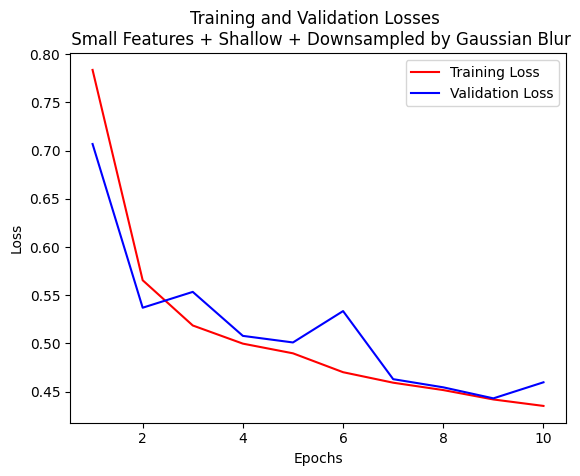

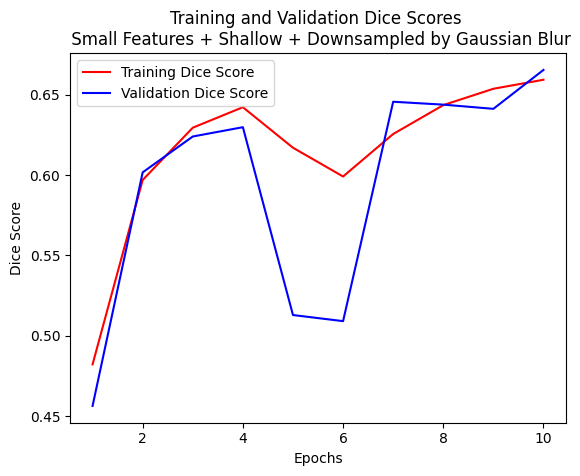

Train Loss: 0.435180415384105
Train DICE Score: 0.659385227888334
Validation Loss: 0.4596932890974445
Validation DICE Score: 0.6655029080532215
Test Loss: 0.455561297175325
Test Dice Score: 0.675080050656825


In [139]:
#plotting training and validation losses/scores
num_epochs = 10
epochs = range(1, num_epochs + 1)
plt.plot(epochs,train_loss,label='Training Loss',color='red')
plt.plot(epochs,val_loss,label='Validation Loss',color='blue')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Losses \n Small Features + Shallow + Downsampled by Gaussian Blur')
plt.legend()
plt.show()

plt.plot(epochs,train_dice_score,label='Training Dice Score',color='red')
plt.plot(epochs,val_dice_score,label='Validation Dice Score',color='blue')
plt.xlabel('Epochs')
plt.ylabel('Dice Score')
plt.title('Training and Validation Dice Scores \n Small Features + Shallow + Downsampled by Gaussian Blur')
plt.legend()
plt.show()

#calculating train,val,test loss/score
print(f"Train Loss: {train_loss[-1]}")
print(f"Train DICE Score: {train_dice_score[-1]}")
print(f"Validation Loss: {val_loss[-1]}")
print(f"Validation DICE Score: {val_dice_score[-1]}")
test(model,loss_function)

In [146]:
pip install nilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 89.7 MB/s eta 0:00:00


Ground Truth Segmentation:


/tmp/ipykernel_5324/3064379071.py:43: UserWarning: Specified vmin=0 and vmax=4 values do not create a symmetric colorbar. The values will be modified to be symmetric.
  view_gt = plotting.view_img(



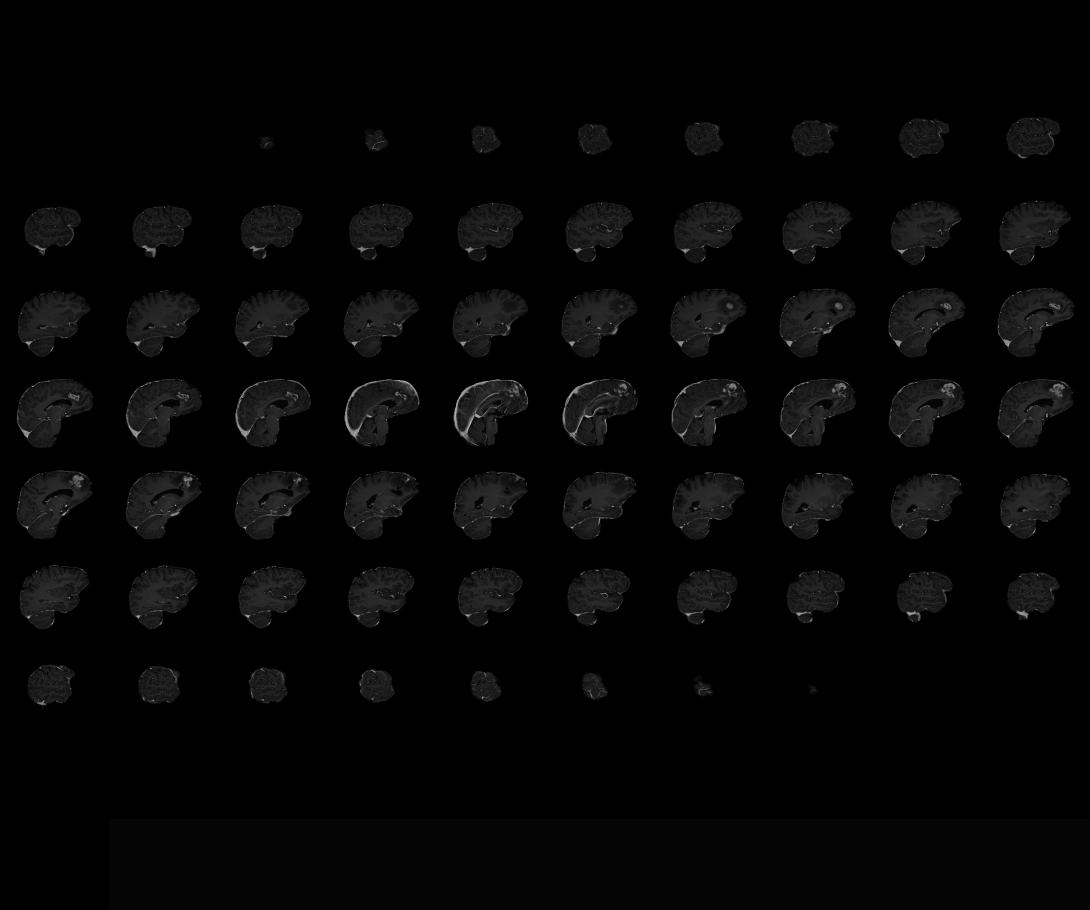
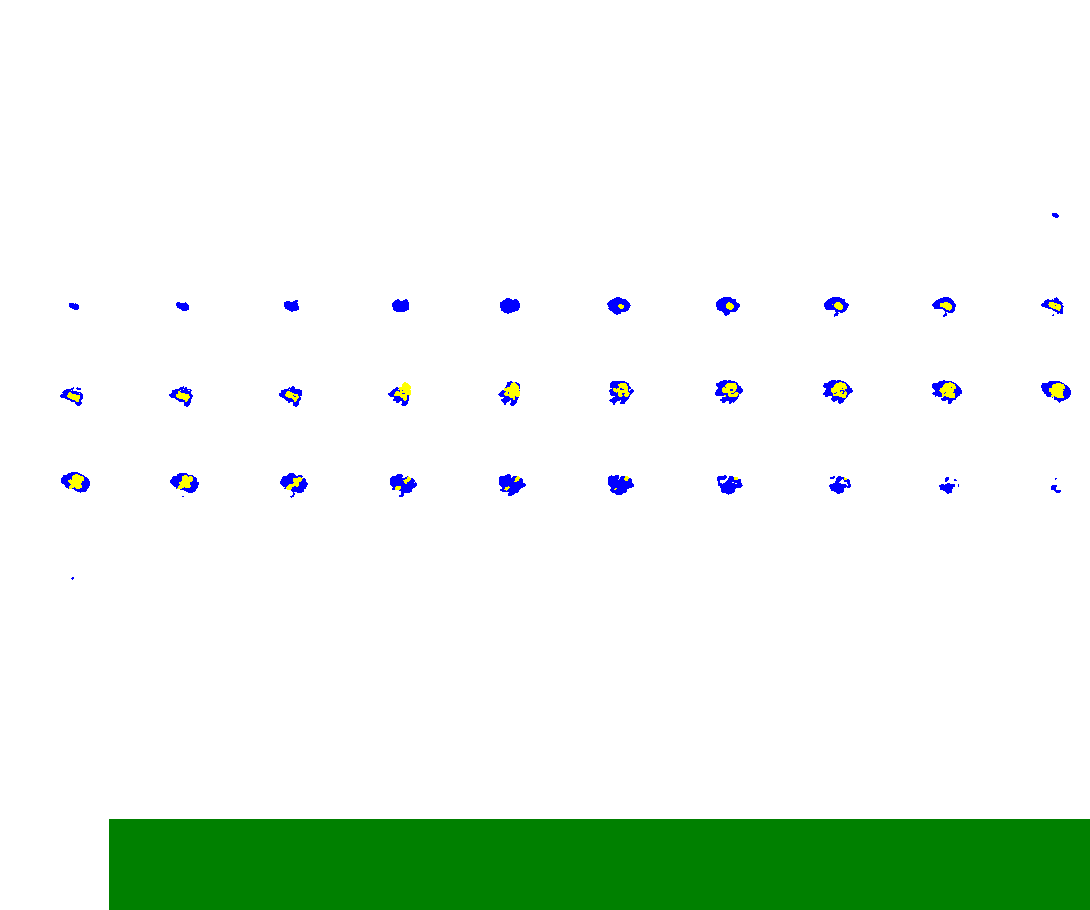

Predicted Segmentation:


/tmp/ipykernel_5324/3064379071.py:56: UserWarning: Specified vmin=0 and vmax=4 values do not create a symmetric colorbar. The values will be modified to be symmetric.
  view_pred = plotting.view_img(



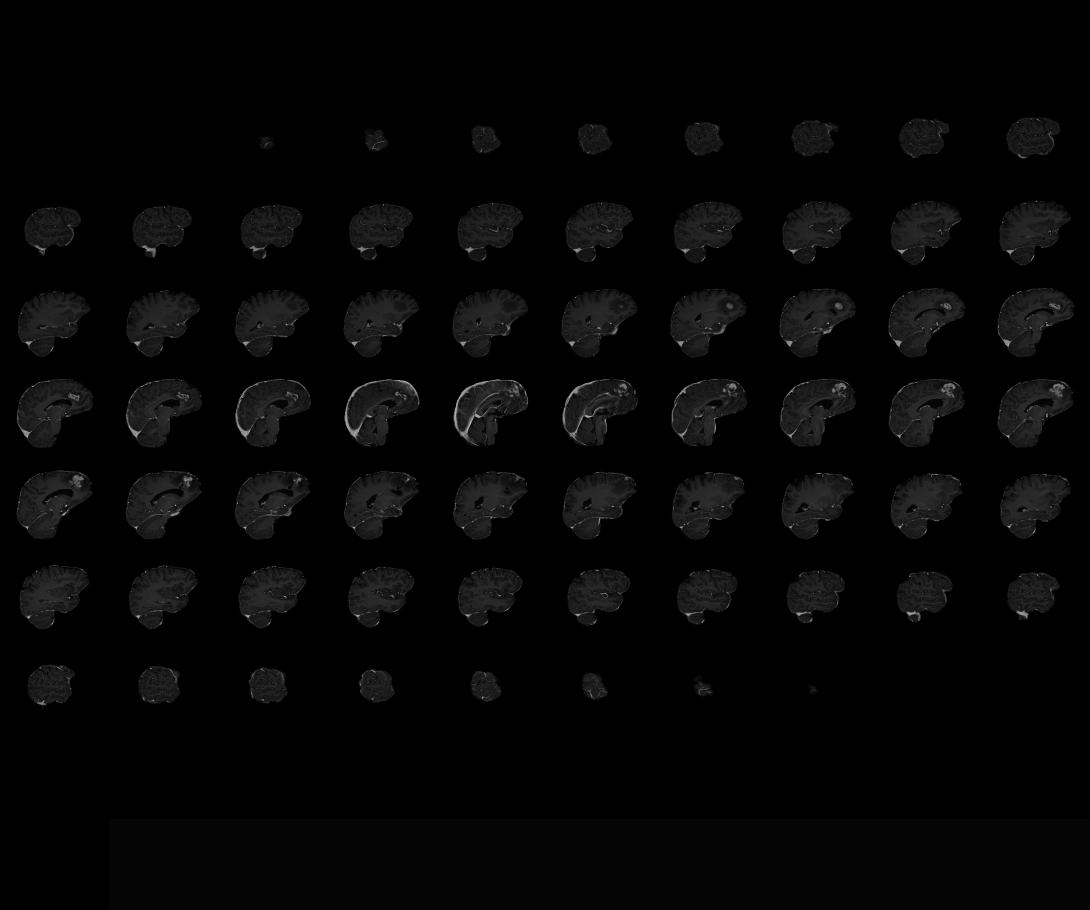
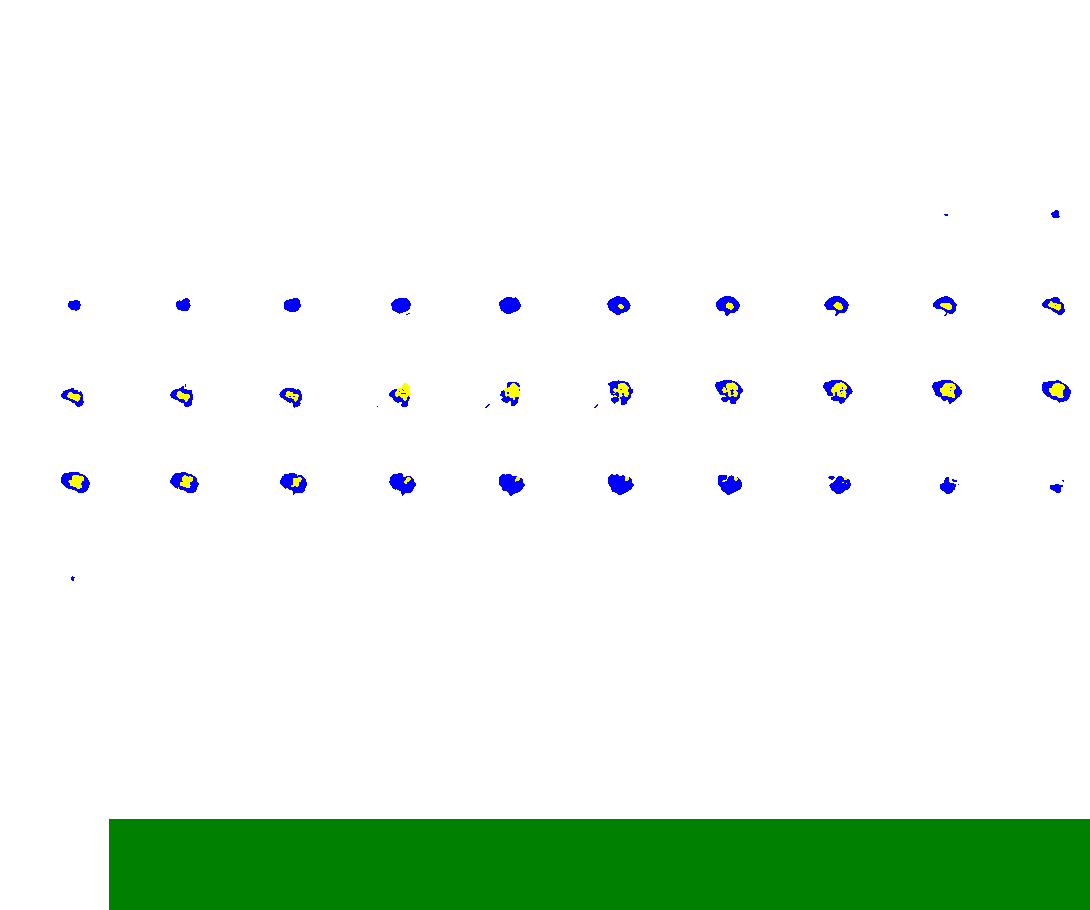

In [154]:
#plotting slices of predicted and actual segmentation mask

import nibabel
import matplotlib.colors as mcolors
import random
import numpy as np
from nilearn import plotting, image
from IPython.display import display

test_loader_2 = DataLoader(test_set,batch_size=1,shuffle=True)
indx = 100

def test_output(model,indx):
    model.eval()
    data_list = list(test_loader_2)
    inputs,labels = data_list[indx]
    inputs = inputs.to(device)
    inputs = inputs.squeeze(1)
    outputs = model.forward(inputs)
    return inputs,outputs,labels

inputs, outputs, labels = test_output(model,indx)

outputs = F.softmax(outputs,dim=1)
predicted_segmentation = torch.argmax(outputs,dim=1)

t2w_data_np = inputs[0,0,:,:,:].cpu().detach().numpy()
ground_truth_seg_np = labels[0,:,:,:].cpu().detach().numpy()
predicted_seg_np = predicted_segmentation[0,:,:,:].cpu().detach().numpy()

anat_img = image.new_img_like(image.load_img(nibabel.Nifti1Image(t2w_data_np, np.eye(4))), t2w_data_np)

ground_truth_seg_img = nibabel.Nifti1Image(ground_truth_seg_np.astype(np.int16), anat_img.affine)
predicted_seg_img = nibabel.Nifti1Image(predicted_seg_np.astype(np.int16), anat_img.affine)

colors = [(0, 0, 0, 0), "red", "green", "blue", "yellow"]
cmap_seg = mcolors.ListedColormap(colors)

cut_coords = (45, 54, 45)


print("Ground Truth Segmentation:")
view_gt = plotting.view_img(
    ground_truth_seg_img,
    bg_img=anat_img,
    cmap=cmap_seg,
    vmin=0, vmax=4,
    resampling_interpolation='nearest',
    title="Ground Truth",
    colorbar=False,
    cut_coords=cut_coords
)
display(view_gt)

print("Predicted Segmentation:")
view_pred = plotting.view_img(
    predicted_seg_img,
    bg_img=anat_img,
    cmap=cmap_seg,
    vmin=0, vmax=4,
    resampling_interpolation='nearest',
    title="Prediction",
    colorbar=False,
    cut_coords=cut_coords
)
display(view_pred)

Generating 3D Matplotlib Surface Plot for Ground Truth...


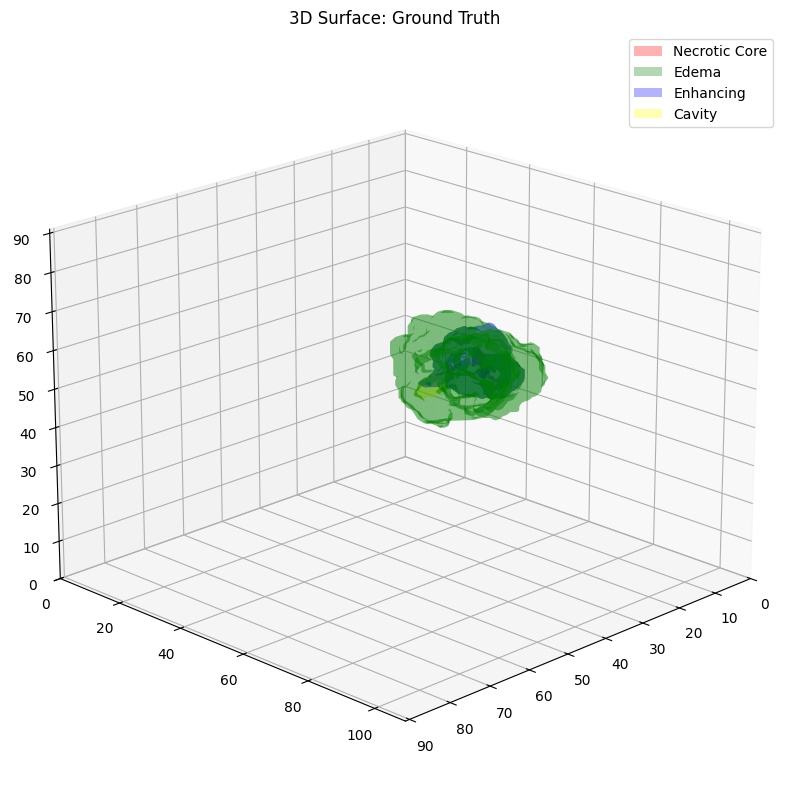

Generating 3D Matplotlib Surface Plot for Prediction...


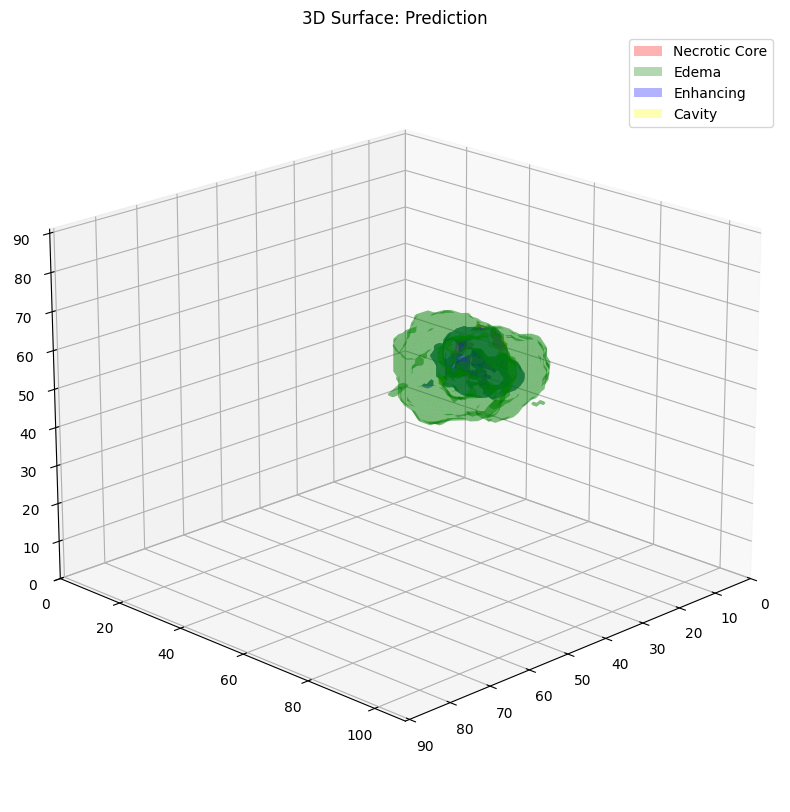

In [155]:
#plotting 3d mesh of predicted and actual segmentation mask
from skimage import measure
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def plot_3d_mesh(image_data, title="3D Mesh Plot"):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    label_colors = {1: 'red', 2: 'green', 3: 'blue', 4: 'yellow'}
    label_names = {1: 'Necrotic Core', 2: 'Edema', 3: 'Enhancing', 4: 'Cavity'}

    for label, color in label_colors.items():
        binary_mask = (image_data == label).astype(int)

        if np.any(binary_mask):
            # Generate vertices, faces, etc. for 3d visualization
            verts, faces, normals, values = measure.marching_cubes(binary_mask, level=0.5)

            # Creating 3d polygons using vertices, faces, etc.
            mesh = Poly3DCollection(verts[faces], alpha=0.3, label=label_names[label])
            mesh.set_facecolor(color)
            ax.add_collection3d(mesh)

    ax.set_xlim(0, image_data.shape[0])
    ax.set_ylim(0, image_data.shape[1])
    ax.set_zlim(0, image_data.shape[2])

    ax.set_title(title)
    ax.view_init(elev=20, azim=45)
    plt.legend()
    plt.show()

print("Generating 3D Matplotlib Surface Plot for Ground Truth...")
plot_3d_mesh(ground_truth_seg_np, title="3D Surface: Ground Truth")

print("Generating 3D Matplotlib Surface Plot for Prediction...")
plot_3d_mesh(predicted_seg_np, title="3D Surface: Prediction")

In [158]:
#calculating false positives, true positives for each label in the image
import numpy as np

def calculate_fp_tp_per_label(ground_truth, prediction, num_classes=5):

    #calculating false positives, true positive and false positive rate for each label


    fp_counts = {}
    tp_counts = {}
    fp_percentage = {} #

    # Convert ground_truth and prediction to boolean
    ground_truth_bool = ground_truth.astype(bool)
    prediction_bool = prediction.astype(bool)

    # Calculate total number of pixels in the image
    total_pixels = ground_truth.size

    labelList ={1:"Necrotic Tumor Core",2:"Tumor Infiltration and Edema",3:"Enhancing Tumor Core",4:"Resection Cavity"}

    for label in range(1, num_classes): # Iterate through each label, excluding background (0)
        # Create binary masks for the current label
        gt_label_mask = (ground_truth == label)
        pred_label_mask = (prediction == label)

        #Finding the amount of true positives for a given label
        tp = np.sum(gt_label_mask & pred_label_mask)
        tp_counts[labelList[label]] = tp

        #Finding the amount of false positives for a given label
        fp = np.sum(pred_label_mask & ~gt_label_mask)
        fp_counts[labelList[label]] = fp
        if tp+fp != 0:
          p_p = fp/(tp+fp) * 100.0
          fp_percentage[labelList[label]] = p_p
        else:
          fp_percentage[labelList[label]] = "N/A"

    return fp_counts, tp_counts, fp_percentage


fp_labels, tp_labels, fp_p_labels = calculate_fp_tp_per_label(ground_truth_seg_np, predicted_seg_np)

print("\nTrue Positives per label:")
for label, count in tp_labels.items():
    print(f"Label {label}: {count}")

print("\nFalse Positives per label:")
for label, count in fp_labels.items():
    print(f"Label {label}: {count}")

print("\n False Positive Rate per label:")
for label, count in fp_p_labels.items():
    print(f"Label {label}: {count} %")


True Positives per label:
Label Necrotic Tumor Core: 23
Label Tumor Infiltration and Edema: 6178
Label Enhancing Tumor Core: 1915
Label Resection Cavity: 6

False Positives per label:
Label Necrotic Tumor Core: 106
Label Tumor Infiltration and Edema: 1303
Label Enhancing Tumor Core: 100
Label Resection Cavity: 39

 False Positive Rate per label:
Label Necrotic Tumor Core: 82.17054263565892 %
Label Tumor Infiltration and Edema: 17.417457559149845 %
Label Enhancing Tumor Core: 4.962779156327544 %
Label Resection Cavity: 86.66666666666667 %
